<div style="border: 3px solid #2c3e50; border-radius: 12px; padding: 40px 30px; margin: 20px 0; background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%);">

<h4 style="text-align: center; color: #7f8c8d; letter-spacing: 3px; margin-bottom: 5px;">AKADEMIA GÓRNICZO-HUTNICZA IM. STANISŁAWA STASZICA W KRAKOWIE</h4>
<h5 style="text-align: center; color: #95a5a6; margin-top: 0;">Wydział Fizyki i Informatyki Stosowanej</h5>

<div style="text-align: center; margin: 15px 0;">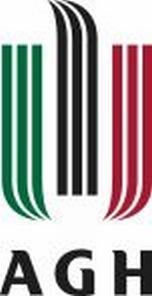</div>

<hr style="border: 1px solid #bdc3c7; width: 60%; margin: 25px auto;">

<h5 style="text-align: center; color: #7f8c8d; letter-spacing: 2px; margin-bottom: 5px;">KURS</h5>
<h2 style="text-align: center; color: #2c3e50; margin-top: 0;">Analiza i przetwarzanie obrazów</h2>

<br>

<h1 style="text-align: center; color: #1a5276; font-size: 2.2em; margin: 20px 0 5px;">Sprawozdanie — Laboratorium 5–7</h1>
<h3 style="text-align: center; color: #2980b9; font-weight: normal; font-style: italic; margin-top: 5px;">Wykrywanie krawędzi, analiza sekwencji wideo, rozpoznawanie cech</h3>

<hr style="border: 1px solid #bdc3c7; width: 60%; margin: 30px auto;">

<table style="margin: 0 auto; border: none; font-size: 1.1em;">
<tr><td style="text-align: right; padding-right: 15px; color: #7f8c8d; border: none;"><b>Autor:</b></td><td style="border: none; color: #2c3e50;">Dawid Piotrowski</td></tr>
<tr><td style="text-align: right; padding-right: 15px; color: #7f8c8d; border: none;"><b>Kierunek:</b></td><td style="border: none; color: #2c3e50;">Informatyka Stosowana, II stopień, semestr I</td></tr>
<tr><td style="text-align: right; padding-right: 15px; color: #7f8c8d; border: none;"><b>Rok akademicki:</b></td><td style="border: none; color: #2c3e50;">2025/2026</td></tr>
</table>

<br>

<p style="text-align: center; color: #aab7b8; font-size: 0.9em;">Kraków, 2026</p>

</div>

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os
import time

plt.rcParams['figure.figsize'] = [16, 8]
plt.rcParams['font.size'] = 12

IMIE_NAZWISKO = "DAWID PIOTROWSKI"
print(f"Autor: {IMIE_NAZWISKO}")
print(f"OpenCV {cv2.__version__}")
print(f"NumPy  {np.__version__}")

---

## Spis treści

1. **[Laboratorium 5 — Wykrywanie krawędzi](#lab5)**
    - [a) Wczytanie obrazu i konwersja do skali szarości](#lab5a)
    - [b) Laplace i Canny — oryginał vs po filtrze Gaussa](#lab5b)
    - [c) Wpływ parametrów algorytmu Canny](#lab5c)
    - [d) Transformacja Hougha — wykrywanie linii prostych](#lab5d)
    - [e) Wpływ progu na transformację Hougha](#lab5e)
    - [f) Wykrywanie okręgów — HoughCircles](#lab5f)

2. **[Laboratorium 6 — Analiza sekwencji wideo](#lab6)**
    - [a) Wykrywanie linii w sekwencji wideo (vid1.mov)](#lab6a)
    - [b) Detekcja ruchu — różnice między klatkami (vid2.mov)](#lab6b)

3. **[Laboratorium 7 — Rozpoznawanie cech i obiektów](#lab7)**
    - [A) Porównanie metod detekcji punktów charakterystycznych](#lab7a)
    - [B) Detekcja twarzy w sekwencji wideo — kaskada Haara](#lab7b)

4. **[Podsumowanie](#podsumowanie)**

---

<a id="lab5"></a>

---

# Laboratorium 5 — Wykrywanie krawędzi

## Wprowadzenie

Wykrywanie krawędzi (*edge detection*) jest jednym z fundamentalnych zagadnień przetwarzania obrazów cyfrowych. **Krawędź** to miejsce na obrazie, w którym zachodzi nagła, lokalna zmiana intensywności pikseli — odpowiada ona granicy między regionami o różnych właściwościach wizualnych (jasność, kolor, tekstura). Precyzyjna detekcja krawędzi stanowi kluczowy etap wielu systemów wizji komputerowej: od segmentacji i rozpoznawania obiektów, przez śledzenie ruchu, aż po rekonstrukcję sceny 3D.

### Metody gradientowe (I pochodna)

Najstarsze i najbardziej intuicyjne podejście do wykrywania krawędzi opiera się na **pierwszej pochodnej** (gradiencie) obrazu. Gradient obrazu $I(x, y)$ definiujemy jako wektor:

$$\nabla I = \begin{bmatrix} \frac{\partial I}{\partial x} \\ \frac{\partial I}{\partial y} \end{bmatrix}$$

Moduł gradientu $|\nabla I| = \sqrt{\left(\frac{\partial I}{\partial x}\right)^2 + \left(\frac{\partial I}{\partial y}\right)^2}$ określa siłę krawędzi, a kąt $\theta = \arctan\left(\frac{\partial I / \partial y}{\partial I / \partial x}\right)$ — jej kierunek. Do tej kategorii należą operatory **Robertsa**, **Prewitta** i **Sobela**, które aproksymują pochodne za pomocą masek konwolucyjnych.

### Operator Laplace'a (II pochodna)

Alternatywne podejście wykorzystuje **drugą pochodną** — operator **Laplace'a** (laplasjan):

$$\nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}$$

Krawędzie odpowiadają **przejściom przez zero** (*zero-crossings*) laplasjanu. Metoda ta jest izotropowa (niezależna od kierunku krawędzi), ale niezwykle wrażliwa na szum — nawet niewielkie zakłócenia generują silne odpowiedzi II pochodnej. Dlatego w praktyce stosuje się filtr **LoG** (*Laplacian of Gaussian*), który najpierw wygładza obraz jądrem Gaussa, a następnie oblicza laplasjan.

### Algorytm Canny'ego

Algorytm zaproponowany przez Johna Canny'ego (1986) jest uznawany za **optymalny detektor krawędzi** w sensie trzech kryteriów:

1. **Minimalna stopa błędów** — wykrywane są tylko prawdziwe krawędzie (niski odsetek fałszywie pozytywnych i fałszywie negatywnych).
2. **Precyzyjna lokalizacja** — wykryta krawędź jest jak najbliżej rzeczywistej.
3. **Jednokrotna odpowiedź** — każda krawędź jest oznaczona dokładnie raz.

Algorytm Canny'ego realizuje wieloetapowy potok:

1. **Wygładzanie gaussowskie** — redukcja szumu filtrem $G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}}$
2. **Obliczenie gradientu** — za pomocą operatora Sobela w dwóch kierunkach
3. **Tłumienie niemaksymalne** (*non-maximum suppression*) — zachowanie tylko pikseli o lokalnie maksymalnym gradiencie wzdłuż kierunku krawędzi
4. **Podwójne progowanie z histerezą** — piksele o gradiencie powyżej progu górnego (*maxVal*) to **silne krawędzie**; piksele między progiem dolnym (*minVal*) a górnym to **słabe krawędzie**, zachowywane tylko jeśli sąsiadują z silną krawędzią

### Transformacja Hougha

Transformacja Hougha (*Hough Transform*, 1962) to technika głosowania w przestrzeni parametrów, która pozwala wykrywać obiekty o znanym kształcie parametrycznym (linie proste, okręgi, elipsy) na mapie krawędzi. Dla **linii prostych** każdy punkt krawędzi $(x_i, y_i)$ generuje sinusoidalną krzywą w przestrzeni $(\rho, \theta)$:

$$\rho = x_i \cos\theta + y_i \sin\theta$$

Przecięcia sinusoid w akumulatorze wskazują parametry linii, na których leży wiele punktów krawędzi. Dla **okręgów** $(x - a)^2 + (y - b)^2 = r^2$ przestrzeń parametrów jest trójwymiarowa $(a, b, r)$.

> **Obrazy testowe:** `lab5_1.jpg` — fotografia drogi E22 z wyraźnymi liniami jezdni, idealny materiał do detekcji krawędzi i transformacji Hougha; `lab5_2.png` — kolaż okrągłych znaków drogowych, doskonały do testowania detekcji okręgów.

<a id="lab5a"></a>

### Zadanie a) Wczytanie obrazu lab5_1.jpg i konwersja do skali szarości

Wczytujemy obraz `lab5_1.jpg` — fotografię drogi E22. Konwersja do skali szarości jest niezbędnym krokiem wstępnym dla algorytmów detekcji krawędzi, które operują na jednowymiarowej funkcji intensywności $I(x,y)$. OpenCV stosuje standardową formułę luminancji ITU-R BT.601:

$$Y = 0{,}299 \cdot R + 0{,}587 \cdot G + 0{,}114 \cdot B$$

Wagi te odpowiadają percepcji jasności przez ludzkie oko — kanał zielony ma największy wkład, ponieważ receptory typu M (*medium-wavelength*) dominują w siatkówce.

In [ ]:
# --- Lab 5a: Wczytanie obrazu i konwersja do szarości ---
img5_bgr = cv2.imread('../images/lab5_1.jpg')
assert img5_bgr is not None, "Nie udało się wczytać obrazu lab5_1.jpg!"

img5_rgb = cv2.cvtColor(img5_bgr, cv2.COLOR_BGR2RGB)
gray5 = cv2.cvtColor(img5_bgr, cv2.COLOR_BGR2GRAY)

h, w = gray5.shape
print(f"Rozmiar obrazu:  {w} x {h} px")
print(f"Typ danych:      {gray5.dtype}")
print(f"Zakres wartości: [{gray5.min()}, {gray5.max()}]")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(img5_rgb)
axes[0].set_title('Obraz oryginalny — lab5_1.jpg')
axes[0].axis('off')
axes[1].imshow(gray5, cmap='gray')
axes[1].set_title('Skala szarości')
axes[1].axis('off')
plt.tight_layout()
plt.show()

#### Obserwacje

Obraz przedstawia prostą drogę z wyraźnymi liniami krawędziowymi jezdni. Po konwersji do skali szarości zachowane zostały kluczowe cechy strukturalne:
- **Kontrastowe linie jezdni** (jasne pasy na ciemnym asfalcie) — idealne dla detektora krawędzi
- **Gradient jasności nieba** — potencjalne źródło fałszywych krawędzi na granicy horyzont–niebo
- **Tekstura roślinności** po bokach drogi — drobnoziarniste zmiany intensywności

<a id="lab5b"></a>

### Zadanie b) Laplace i Canny — oryginał vs po filtrze Gaussa (5x5)

Porównujemy dwa fundamentalnie różne podejścia do detekcji krawędzi:

- **Laplasjan** — operator II pochodnej, izotropowy, ale wrażliwy na szum
- **Canny** — wieloetapowy algorytm optymalny z tłumieniem niemaksymalnym i histerezą

Każdą metodę stosujemy dwukrotnie: bezpośrednio na obrazie oryginalnym oraz po wstępnym rozmyciu filtrem **Gaussa** o jądrze 5x5. Celem jest wykazanie, że wstępne wygładzanie eliminuje odpowiedzi na szum, pozostawiając jedynie istotne krawędzie strukturalne.

Laplasjan obliczamy na danych typu `CV_64F` (zmiennoprzecinkowych), aby zachować wartości ujemne, a następnie bierzemy wartość bezwzględną:

$$L(x,y) = |\nabla^2 I(x,y)| = \left|\frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}\right|$$

In [ ]:
# --- Lab 5b: Laplace i Canny — oryginał vs Gauss ---
gauss5 = cv2.GaussianBlur(gray5, (5, 5), 0)

# Laplasjan na oryginale i po Gaussie
lap_orig  = np.clip(np.abs(cv2.Laplacian(gray5,  cv2.CV_64F)), 0, 255).astype(np.uint8)
lap_gauss = np.clip(np.abs(cv2.Laplacian(gauss5, cv2.CV_64F)), 0, 255).astype(np.uint8)

# Canny na oryginale i po Gaussie
can_orig  = cv2.Canny(gray5,  50, 150)
can_gauss = cv2.Canny(gauss5, 50, 150)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
titles = ['Laplace — oryginał', 'Laplace — po Gaussie 5x5',
          'Canny (50, 150) — oryginał', 'Canny (50, 150) — po Gaussie 5x5']
images = [lap_orig, lap_gauss, can_orig, can_gauss]

for ax, im, title in zip(axes.flat, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.suptitle('Porównanie detektorów krawędzi: Laplace vs Canny', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statystyki
print(f"Laplace oryginał  — piksele niezerowe: {np.count_nonzero(lap_orig):>7} ({100*np.count_nonzero(lap_orig)/(h*w):.1f}%)")
print(f"Laplace Gauss     — piksele niezerowe: {np.count_nonzero(lap_gauss):>7} ({100*np.count_nonzero(lap_gauss)/(h*w):.1f}%)")
print(f"Canny oryginał    — piksele krawędzi:  {np.count_nonzero(can_orig):>7} ({100*np.count_nonzero(can_orig)/(h*w):.1f}%)")
print(f"Canny Gauss       — piksele krawędzi:  {np.count_nonzero(can_gauss):>7} ({100*np.count_nonzero(can_gauss)/(h*w):.1f}%)")

#### Analiza wyników

Porównanie ujawnia fundamentalne różnice między oboma podejściami:

| Cecha | Laplasjan | Canny |
|-------|-----------|-------|
| Typ odpowiedzi | Ciągłe wartości intensywności | Binarna mapa krawędzi (0/255) |
| Grubość krawędzi | Szerokie, rozmyte pasma | Cienkie, 1-pikselowe krawędzie |
| Wrażliwość na szum | **Bardzo wysoka** — II pochodna wzmacnia szum | Niska — wbudowane wygładzanie + histereza |
| Efekt Gaussa | Drastyczna redukcja szumu, ale utrata drobnych krawędzi | Subtelne wygładzenie, stabilne krawędzie |

**Kluczowe obserwacje:**

1. **Laplasjan bez wygładzania** reaguje na każdą mikrozmianę intensywności — obraz wyjściowy jest pełen odpowiedzi na teksturę i artefakty kompresji JPEG. To klasyczny problem operatorów II pochodnej: $\nabla^2(I + n) = \nabla^2 I + \nabla^2 n$, gdzie szum $n$ jest wzmacniany proporcjonalnie do jego częstotliwości.

2. **Laplasjan po Gaussie** daje znacznie czystszy wynik — odpowiada to operatorowi **LoG** (*Laplacian of Gaussian*), który można aproksymować różnicą gaussjanów (**DoG**):
$$\text{LoG}(x,y) \approx \frac{G(x,y,\sigma_1) - G(x,y,\sigma_2)}{\sigma_1^2 - \sigma_2^2}$$

3. **Canny** produkuje cienkie, dobrze zlokalizowane krawędzie dzięki trzem mechanizmom:
   - *Non-maximum suppression* — zachowuje tylko piksel o maksymalnym gradiencie wzdłuż kierunku prostopadłego do krawędzi
   - *Podwójne progowanie* — eliminuje słabe odpowiedzi niebędące kontynuacją silnych krawędzi
   - *Śledzenie krawędzi* (*edge tracing*) — łączy słabe krawędzie z silnymi poprzez sąsiedztwo 8-kierunkowe

4. **Gaussowskie wygładzenie przed Canny** ma mniejszy efekt niż przed Laplace'em, ponieważ Canny *wewnętrznie* wykonuje wygładzanie (choć z domyślnym, stosunkowo małym jądrem). Dodatkowy filtr Gaussa eliminuje jedynie najdrobniejsze szczegóły.

<a id="lab5c"></a>

### Zadanie c) Wpływ parametrów algorytmu Canny

Badamy wpływ trzech kluczowych parametrów `cv2.Canny(image, minVal, maxVal, apertureSize)` na wynik detekcji krawędzi:

- **minVal** — dolny próg histerezy. Piksele o gradiencie $|\nabla I| < \text{minVal}$ są definitywnie odrzucane.
- **maxVal** — górny próg histerezy. Piksele o $|\nabla I| > \text{maxVal}$ są uznawane za silne krawędzie.
- **apertureSize** — rozmiar jądra Sobela ($3 \times 3$, $5 \times 5$ lub $7 \times 7$) używanego do obliczenia gradientu.

Algorytm histerezy działa następująco:

$$\text{piksel} = \begin{cases} \textbf{krawędź silna} & \text{jeśli } |\nabla I| > \text{maxVal} \\ \textbf{krawędź słaba} & \text{jeśli } \text{minVal} \leq |\nabla I| \leq \text{maxVal} \\ \textbf{odrzucony} & \text{jeśli } |\nabla I| < \text{minVal} \end{cases}$$

Krawędź słaba jest zachowywana **wyłącznie** jeśli jest połączona (w sensie 8-sąsiedztwa) z krawędzią silną.

In [ ]:
# --- Lab 5c: Wpływ parametrów Canny ---
configs = [
    (30,  90,  3, 'minVal=30, maxVal=90, apt=3'),
    (50,  150, 3, 'minVal=50, maxVal=150, apt=3'),
    (100, 200, 3, 'minVal=100, maxVal=200, apt=3'),
    (50,  150, 5, 'minVal=50, maxVal=150, apt=5'),
    (50,  150, 7, 'minVal=50, maxVal=150, apt=7'),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, (mn, mx, apt, title) in zip(axes, configs):
    edges = cv2.Canny(gauss5, mn, mx, apertureSize=apt)
    n_edge = np.count_nonzero(edges)
    ax.imshow(edges, cmap='gray')
    ax.set_title(f'{title}\n({n_edge} pikseli)', fontsize=9)
    ax.axis('off')

plt.suptitle('Wpływ parametrów algorytmu Canny na detekcję krawędzi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Analiza wpływu parametrów

**Wpływ progów minVal / maxVal (przy stałym apertureSize = 3):**

| Konfiguracja | Charakterystyka wyniku |
|:---:|:---|
| **(30, 90)** | Niskie progi — wykrywane są praktycznie wszystkie krawędzie, w tym bardzo słabe odpowiedzi na teksturę asfaltu, roślinność i szum. Mapa krawędzi jest gęsta. |
| **(50, 150)** | Umiarkowane progi — dobry kompromis między czułością a selektywnością. Widoczne główne krawędzie strukturalne (linie jezdni, krawędzie drogi, kontury obiektów), odfiltrowany szum. |
| **(100, 200)** | Wysokie progi — zachowane jedynie najsilniejsze krawędzie. Pewne istotne kontury mogą być utracone, ale wynik jest bardzo czysty. |

> **Reguła kciuka (Canny, 1986):** zalecany stosunek progów to $\text{maxVal} / \text{minVal} \approx 2{:}1$ do $3{:}1$. Zbyt mały stosunek powoduje fragmentację krawędzi; zbyt duży — nadmierne włączanie słabych odpowiedzi.

**Wpływ apertureSize (przy stałych progach 50/150):**

- **apt = 3** — standardowe jądro Sobela $3 \times 3$. Szybkie obliczenia, dobra lokalizacja krawędzi, ale ograniczona precyzja kierunku gradientu.
- **apt = 5** — jądro $5 \times 5$. Lepsze oszacowanie gradientu (więcej pikseli w kontekście), nieco szersza strefa odpowiedzi, wygładza drobne zaburzenia.
- **apt = 7** — jądro $7 \times 7$. Najprecyzyjniejsze oszacowanie gradientu, ale kosztem obliczeniowym i możliwą utratą najdrobniejszych detali.

Większe jądro Sobela efektywnie wykonuje dodatkowe wygładzanie — odpowiedź na szum maleje proporcjonalnie do $1/n^2$, gdzie $n$ to rozmiar jądra.

<a id="lab5d"></a>

### Zadanie d) Transformacja Hougha — wykrywanie linii prostych

**Transformacja Hougha** (*Hough Transform*, 1962) to elegancka technika wykrywania kształtów parametrycznych na mapie krawędzi. Dla **linii prostych** wykorzystujemy parametryzację normalną (Hesse\'a):

$$\rho = x\cos\theta + y\sin\theta$$

gdzie $\rho$ to odległość linii od początku układu współrzędnych, a $\theta \in [0, \pi)$ to kąt normalnej do linii względem osi $x$.

**Algorytm:**
1. Dla każdego piksela krawędzi $(x_i, y_i)$ oblicz sinusoidę w przestrzeni $(\rho, \theta)$
2. Inkrementuj komórki akumulatora $A(\rho, \theta)$ wzdłuż tej sinusoidy
3. Wartości w akumulatorze powyżej progu *threshold* wskazują parametry wykrytych linii

Złożoność obliczeniowa to $O(N \cdot M_\theta)$, gdzie $N$ to liczba pikseli krawędzi, a $M_\theta$ — rozdzielczość kątowa akumulatora. W OpenCV `cv2.HoughLines()` domyślnie stosuje $\Delta\rho = 1$ piksel i $\Delta\theta = \pi/180$ radiana.

In [ ]:
# --- Lab 5d: Transformacja Hougha — wykrywanie linii ---
edges5 = cv2.Canny(gauss5, 50, 150)
lines5 = cv2.HoughLines(edges5, 1, np.pi / 180, threshold=100)

img_lines5 = img5_rgb.copy()
if lines5 is not None:
    for line in lines5:
        rho, theta = line[0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho
        pt1 = (int(x0 + 2000 * (-b)), int(y0 + 2000 * a))
        pt2 = (int(x0 - 2000 * (-b)), int(y0 - 2000 * a))
        cv2.line(img_lines5, pt1, pt2, (255, 0, 0), 2)

n_lines = len(lines5) if lines5 is not None else 0
print(f"Wykryto linii: {n_lines}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img5_rgb)
axes[0].set_title('Obraz oryginalny')
axes[0].axis('off')
axes[1].imshow(edges5, cmap='gray')
axes[1].set_title('Mapa krawędzi (Canny)')
axes[1].axis('off')
axes[2].imshow(img_lines5)
axes[2].set_title(f'Transformacja Hougha — {n_lines} linii (próg=100)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

#### Analiza wyników transformacji Hougha

Transformacja Hougha skutecznie wykrywa dominujące linie proste na obrazie — przede wszystkim **krawędzie jezdni** oraz **linie pasów ruchu**. Warto zwrócić uwagę na kilka aspektów:

1. **Linie są nieskończone** — `cv2.HoughLines()` zwraca parametry $(\rho, \theta)$ opisujące prostą rozciągającą się na cały obraz. W praktycznych zastosowaniach (np. detekcja pasów ruchu) preferuje się `cv2.HoughLinesP()` (*probabilistic Hough*), która zwraca **odcinki** o skończonej długości.

2. **Redundancja** — wiele linii może opisywać tę samą krawędź fizyczną, ale z nieznacznie różnymi parametrami. Rozwiązaniem jest grupowanie (*clustering*) wyników lub stosowanie tłumienia niemaksymalnego w akumulatorze.

3. **Zależność od jakości mapy krawędzi** — transformacja Hougha operuje na *binarnej* mapie krawędzi. Jeśli detekcja krawędzi jest niedokładna (za dużo szumu lub zbyt restrykcyjne progi), wynik Hougha będzie proporcjonalnie gorszy.

> **Uwaga implementacyjna:** Linie rysujemy od punktu $(x_0 - 2000b, y_0 + 2000a)$ do $(x_0 + 2000b, y_0 - 2000a)$, gdzie $(x_0, y_0) = (\rho\cos\theta, \rho\sin\theta)$ jest punktem na prostej najbliższym początkowi układu. Wartość 2000 zapewnia, że linia rozciąga się poza granice obrazu.

<a id="lab5e"></a>

### Zadanie e) Wpływ progu na transformację Hougha

Próg (*threshold*) w transformacji Hougha określa minimalną liczbę głosów w akumulatorze — czyli minimalną liczbę punktów krawędzi, które muszą leżeć na danej prostej, aby została ona uznana za wykrytą. Badamy wpływ progu na liczbę i jakość wykrytych linii.

In [ ]:
# --- Lab 5e: Wpływ progu na transformację Hougha ---
thresholds = [50, 100, 150, 200]

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, thr in zip(axes, thresholds):
    result = img5_rgb.copy()
    lines_t = cv2.HoughLines(edges5, 1, np.pi / 180, threshold=thr)
    n = 0
    if lines_t is not None:
        n = len(lines_t)
        for line in lines_t:
            rho, theta = line[0]
            a, b = np.cos(theta), np.sin(theta)
            x0, y0 = a * rho, b * rho
            pt1 = (int(x0 + 2000 * (-b)), int(y0 + 2000 * a))
            pt2 = (int(x0 - 2000 * (-b)), int(y0 - 2000 * a))
            cv2.line(result, pt1, pt2, (255, 0, 0), 2)
    ax.imshow(result)
    ax.set_title(f'Próg = {thr}\n({n} linii)')
    ax.axis('off')

plt.suptitle('Wpływ progu akumulatora na liczbę wykrytych linii (Hough)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Analiza wpływu progu

| Próg | Liczba linii | Charakterystyka |
|:----:|:---:|:---|
| **50** | Dużo | Wykrywane są nawet krótkie, mało istotne linie — tekstura, drobne krawędzie. Obraz jest zaśmiecony fałszywie pozytywnymi detekcjami. |
| **100** | Umiarkowana | Dobry kompromis — widoczne główne krawędzie jezdni, odfiltrowane drobne artefakty. |
| **150** | Niewiele | Zachowane jedynie dominujące linie — najpewniejsze struktury na obrazie. |
| **200** | Bardzo mało | Tylko najsilniejsze linie — ryzyko pominięcia istotnych krawędzi. |

**Wnioski:**

- Próg jest **liniowo** powiązany z długością minimalną wykrywanej linii (przy stałej rozdzielczości akumulatora $\Delta\rho = 1$ piksel, próg $T$ oznacza, że linia musi zawierać co najmniej $T$ pikseli krawędzi).
- W zastosowaniach praktycznych optymalny próg dobiera się **adaptacyjnie**, np. jako procent maksymalnej wartości akumulatora lub na podstawie statystyk rozkładu głosów.
- Alternatywą jest **probabilistyczna transformacja Hougha** (`cv2.HoughLinesP()`), która dodatkowo filtruje wynik na podstawie długości odcinków i maksymalnej przerwy (*maxLineGap*).

<a id="lab5f"></a>

### Zadanie f) Wykrywanie okręgów — HoughCircles

Uogólniona transformacja Hougha pozwala wykrywać dowolne krzywe parametryczne. Dla **okręgów** o równaniu $(x-a)^2 + (y-b)^2 = r^2$ przestrzeń parametrów jest trójwymiarowa: $(a, b, r)$ — centrum i promień.

OpenCV implementuje wariant **gradientowy** (`HOUGH_GRADIENT`), który redukuje złożoność obliczeniową dzięki wykorzystaniu kierunku gradientu do ograniczenia głosowania:

1. Dla każdego piksela krawędzi oblicz kierunek gradientu
2. Głosuj tylko wzdłuż linii wyznaczonej przez gradient (potencjalne centra okręgu)
3. Dla najsilniejszych kandydatów na centra, zbadaj rozkład odległości do pikseli krawędzi i wyznacz promień

Kluczowe parametry `cv2.HoughCircles()`:
- **dp** — odwrotna rozdzielczość akumulatora (dp=1 oznacza pełną rozdzielczość)
- **minDist** — minimalna odległość między centrami wykrytych okręgów
- **param1** — górny próg Canny (dolny = param1/2)
- **param2** — próg akumulatora (mniejszy oznacza więcej okręgów, więcej fałszywych)
- **minRadius, maxRadius** — zakres promieni

Obraz `lab5_2.png` zawiera kolaż okrągłych znaków drogowych — idealny materiał testowy.

In [ ]:
# --- Lab 5f: Wykrywanie okręgów — HoughCircles ---
img52_bgr = cv2.imread('../images/lab5_2.png')
assert img52_bgr is not None, "Nie udało się wczytać obrazu lab5_2.png!"

img52_rgb = cv2.cvtColor(img52_bgr, cv2.COLOR_BGR2RGB)
gray52 = cv2.cvtColor(img52_bgr, cv2.COLOR_BGR2GRAY)
blur52 = cv2.GaussianBlur(gray52, (9, 9), 2)

circles = cv2.HoughCircles(
    blur52, cv2.HOUGH_GRADIENT,
    dp=1, minDist=30,
    param1=50, param2=30,
    minRadius=0, maxRadius=0
)

result52 = img52_rgb.copy()
n_circles = 0
if circles is not None:
    circles_rounded = np.uint16(np.around(circles[0]))
    n_circles = len(circles_rounded)
    for c in circles_rounded:
        cv2.circle(result52, (c[0], c[1]), c[2], (0, 255, 0), 2)   # okrąg
        cv2.circle(result52, (c[0], c[1]), 3,    (255, 0, 0), -1)  # centrum

print(f"Wykryto okręgów: {n_circles}")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(img52_rgb)
axes[0].set_title('Obraz oryginalny — lab5_2.png')
axes[0].axis('off')
axes[1].imshow(result52)
axes[1].set_title(f'HoughCircles — wykryto {n_circles} okręgów')
axes[1].axis('off')
plt.tight_layout()
plt.show()

#### Analiza detekcji okręgów

Obraz `lab5_2.png` zawiera kolaż znaków drogowych, z których wiele ma kształt okrągły (znaki zakazu, nakazu, ostrzegawcze). Metoda `HoughCircles` z wariantem gradientowym powinna wykryć większość z nich.

**Obserwacje:**

1. **Trafne detekcje** — okręgi odpowiadające rzeczywistym konturom znaków drogowych. Zielone okręgi prawidłowo obejmują okrągłe znaki zakazu i nakazu.

2. **Fałszywe pozytywy** — mogą pojawić się na elementach, które lokalnie przypominają łuki okręgów (np. narożniki znaków trójkątnych, elementy tła). Redukcja fałszywych pozytywów wymaga zwiększenia `param2` lub zawężenia zakresu promieni.

3. **Wpływ parametrów:**
   - **param1 = 50** — próg Canny (wewnętrzny). Niższy oznacza więcej pikseli krawędzi wchodzących do akumulatora.
   - **param2 = 30** — próg akumulatora. Niższy oznacza łatwiejsze zebranie wystarczającej liczby głosów.
   - **minDist = 30** — zapobiega nakładaniu się wykrytych okręgów (zachowuje tylko silniejszy z dwóch bliskich kandydatów).

4. **Rozmycie gaussowskie** (9x9, $\sigma=2$) jest kluczowe — bez niego szum powoduje eksplozję fałszywych odpowiedzi w akumulatorze.

> **Uwaga:** `cv2.HoughCircles()` wewnętrznie stosuje detektor Canny, więc nie ma potrzeby wcześniejszego wywoływania `cv2.Canny()`. Parametr `param1` pełni rolę górnego progu Canny, a dolny próg jest automatycznie ustawiany na `param1 / 2`.

<a id="lab6"></a>

---

# Laboratorium 6 — Analiza sekwencji wideo

## Wprowadzenie

Przetwarzanie sekwencji wideo (*video processing*) stanowi naturalne rozszerzenie analizy obrazów statycznych o wymiar czasowy. Sekwencja wideo to uporządkowany ciąg klatek (*frames*), z których każda jest pełnoprawnym obrazem rastrowym. Częstotliwość odświeżania (*frame rate*), wyrażana w klatkach na sekundę (FPS — *frames per second*), determinuje płynność odtwarzania i rozdzielczość czasową analizy.

### Przetwarzanie klatka po klatce

Podstawowy paradygmat analizy wideo polega na sekwencyjnym przetwarzaniu każdej klatki niezależnie — stosujemy te same algorytmy co dla obrazów statycznych (detekcja krawędzi, segmentacja, rozpoznawanie obiektów), ale na potoku klatek. Kluczowe klasy OpenCV:

- **`cv2.VideoCapture()`** — odczyt wideo z pliku lub kamery. Metoda `read()` zwraca kolejną klatkę jako macierz BGR.
- **`cv2.VideoWriter()`** — zapis przetworzonego wideo do pliku. Wymaga podania kodeka (`fourcc`), FPS i rozdzielczości.

### Wyzwania przetwarzania wideo

Analiza wideo niesie ze sobą specyficzne wyzwania, które nie występują w przypadku obrazów statycznych:

1. **Niespójność czasowa** (*temporal inconsistency*) — wynik przetwarzania poszczególnych klatek może się drastycznie różnić, powodując efekt migotania
2. **Wydajność obliczeniowa** — przetwarzanie w czasie rzeczywistym wymaga analizy 25-60 klatek/s
3. **Kompresja wideo** — artefakty kodera (blokowe, pierścieniowe) wpływają na jakość detekcji
4. **Detekcja ruchu** — wymaga porównywania klatek w dziedzinie czasowej

> **Materiały wideo:** `vid1.mov` — nagranie z kamery, odpowiednie do detekcji linii transformacją Hougha; `vid2.mov` — sekwencja z ruchomymi obiektami, materiał do detekcji ruchu metodą różnic klatek.

<a id="lab6a"></a>

### Zadanie a) Wykrywanie linii w sekwencji wideo — vid1.mov

Aplikujemy transformację Hougha do każdej klatki wideo `vid1.mov`. Potok przetwarzania dla każdej klatki:

1. Konwersja BGR do skali szarości
2. Rozmycie gaussowskie (5x5) — redukcja szumu
3. Detekcja krawędzi algorytmem Canny (progi 50/150)
4. Transformacja Hougha z progiem akumulatora 120
5. Narysowanie wykrytych linii na oryginalnej klatce (kolor czerwony)
6. Zapis klatki do pliku wyjściowego

Wynik zapisujemy jako `../output/lab6_hough.mp4` z oryginalnym FPS i rozdzielczością.

In [ ]:
# --- Lab 6a: Wykrywanie linii w wideo (Hough) ---
cap = cv2.VideoCapture('../videos/vid1.mov')
assert cap.isOpened(), "Nie udało się otworzyć vid1.mov!"

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Wideo: {width}x{height}, {fps:.1f} FPS, {total_frames} klatek ({total_frames/fps:.1f} s)")

os.makedirs('images/output', exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('../output/lab6_hough.mp4', fourcc, fps, (width, height))

sample_frame = None
frame_idx = 0
t_start = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, threshold=120)
    
    result = frame.copy()
    if lines is not None:
        for line in lines:
            rho, theta = line[0]
            a, b = np.cos(theta), np.sin(theta)
            x0, y0 = a * rho, b * rho
            pt1 = (int(x0 + 2000 * (-b)), int(y0 + 2000 * a))
            pt2 = (int(x0 - 2000 * (-b)), int(y0 - 2000 * a))
            cv2.line(result, pt1, pt2, (0, 0, 255), 2)
    
    out.write(result)
    
    if frame_idx == total_frames // 2:
        sample_frame = result.copy()
    frame_idx += 1

cap.release()
out.release()
t_elapsed = time.time() - t_start

print(f"Przetworzono {frame_idx} klatek w {t_elapsed:.1f} s ({frame_idx/t_elapsed:.1f} klatek/s)")
print(f"Zapisano: ../output/lab6_hough.mp4")

if sample_frame is not None:
    plt.figure(figsize=(16, 9))
    plt.imshow(cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB))
    plt.title(f'Przykładowa klatka z wykrytymi liniami (Hough, klatka {total_frames // 2})')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

#### Analiza przetwarzania wideo — detekcja linii

Zastosowanie transformacji Hougha klatka po klatce ujawnia zarówno siłę, jak i ograniczenia tego podejścia w kontekście analizy wideo.

**Zaobserwowane zjawiska:**

1. **Niespójność czasowa** (*temporal flickering*) — wykryte linie mogą znacząco różnić się między kolejnymi klatkami. Nawet niewielka zmiana perspektywy lub oświetlenia powoduje przesunięcie krawędzi w mapie Canny, co przekłada się na inne wartości $(\rho, \theta)$ w akumulatorze Hougha. W wynikowym wideo linie mogą skakać lub pojawiać się i znikać.

2. **Redundancja linii** — dla tej samej krawędzi fizycznej (np. pasa ruchu) algorytm często generuje kilka linii o zbliżonych parametrach. Wynika to z dyskretyzacji akumulatora i rozproszenia głosów wokół szczytu.

3. **Wydajność** — potok Gauss, Canny, Hough jest stosunkowo szybki i pozwala na przetwarzanie w czasie zbliżonym do rzeczywistego (zależnie od rozdzielczości).

**Możliwe ulepszenia:**

- **Wygładzanie czasowe** — filtracja parametrów wykrytych linii w dziedzinie czasu (np. filtr Kalmana, średnia krocząca)
- **Region zainteresowania (ROI)** — ograniczenie detekcji do dolnej części kadru (jezdnia), eliminacja fałszywych linii na niebie i budynkach
- **Probabilistyczna transformacja Hougha** (`HoughLinesP`) — zwraca odcinki zamiast prostych, naturalnie filtruje krótkie, mało istotne linie
- **Łączenie z informacją o kierunku** — odrzucanie linii o niewłaściwej orientacji (np. poziomych, gdy szukamy pasów ruchu zbiegających się do punktu zbiegu)

<a id="lab6b"></a>

### Zadanie b) Detekcja ruchu — różnice między klatkami (vid2.mov)

Najprostsza metoda detekcji ruchu opiera się na obliczeniu **bezwzględnej różnicy** między kolejnymi klatkami (*frame differencing*):

$$D_t(x,y) = |I_t(x,y) - I_{t-1}(x,y)|$$

gdzie $I_t$ i $I_{t-1}$ to klatki w chwili $t$ i $t-1$ w skali szarości. Następnie stosujemy progowanie:

$$M_t(x,y) = \begin{cases} 255 & \text{jeśli } D_t(x,y) > T \\ 0 & \text{w przeciwnym razie} \end{cases}$$

Maska binarna $M_t$ wyznacza piksele, w których nastąpiła istotna zmiana — co odpowiada **regionom ruchu**. Nakładamy ją na oryginalną klatkę operacją `bitwise_and`, aby wyodrębnić jedynie poruszające się obiekty.

Klatki skalujemy do 50% oryginalnej rozdzielczości w celu przyspieszenia przetwarzania.

In [ ]:
# --- Lab 6b: Detekcja ruchu — różnice klatek (vid2.mov) ---
cap2 = cv2.VideoCapture('../videos/vid2.mov')
assert cap2.isOpened(), "Nie udało się otworzyć vid2.mov!"

fps2 = cap2.get(cv2.CAP_PROP_FPS)
total2 = int(cap2.get(cv2.CAP_PROP_FRAME_COUNT))
width2 = int(cap2.get(cv2.CAP_PROP_FRAME_WIDTH) * 0.5)
height2 = int(cap2.get(cv2.CAP_PROP_FRAME_HEIGHT) * 0.5)

print(f"Wideo: {width2}x{height2} (50%), {fps2:.1f} FPS, {total2} klatek ({total2/fps2:.1f} s)")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out2 = cv2.VideoWriter('../output/lab6_motion.mp4', fourcc, fps2, (width2, height2))

prev_gray = None
sample2 = None
frame_idx2 = 0
t_start2 = time.time()

while True:
    ret, frame = cap2.read()
    if not ret:
        break
    
    frame = cv2.resize(frame, (width2, height2))
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    if prev_gray is not None:
        diff = cv2.absdiff(gray, prev_gray)
        _, mask = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
        result = cv2.bitwise_and(frame, frame, mask=mask)
        out2.write(result)
        
        if frame_idx2 == total2 // 2:
            sample2 = np.hstack([
                frame,
                cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR),
                result
            ])
    
    prev_gray = gray
    frame_idx2 += 1

cap2.release()
out2.release()
t_elapsed2 = time.time() - t_start2

print(f"Przetworzono {frame_idx2} klatek w {t_elapsed2:.1f} s ({frame_idx2/t_elapsed2:.1f} klatek/s)")
print(f"Zapisano: ../output/lab6_motion.mp4")

if sample2 is not None:
    plt.figure(figsize=(18, 5))
    plt.imshow(cv2.cvtColor(sample2, cv2.COLOR_BGR2RGB))
    plt.title('Detekcja ruchu — klatka oryginalna | maska różnicy | wynik maskowania')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

#### Analiza detekcji ruchu metodą różnic klatek

Metoda różnic klatek jest **najprostszą** techniką detekcji ruchu — wymaga zaledwie jednego odejmowania, progowania i operacji bitowej na klatkę. Mimo prostoty, niesie ze sobą istotne ograniczenia.

**Zalety:**
- Minimalna złożoność obliczeniowa — $O(n)$ na klatkę, gdzie $n$ to liczba pikseli
- Brak konieczności budowania modelu tła
- Natychmiastowa reakcja na ruch (brak opóźnienia adaptacji)

**Ograniczenia:**

| Problem | Opis |
|:--------|:-----|
| Obiekt statyczny | Obiekt, który zatrzymał się, natychmiast znika z maski — metoda wykrywa **zmianę**, nie **obecność** |
| Duchy (*ghosts*) | Na masce pojawiają się dwa kontury obiektu: w pozycji poprzedniej i obecnej |
| Ruch kamery | Jakikolwiek ruch kamery (drgania, obrót) powoduje globalną zmianę pikseli — cała klatka jest oznaczana jako ruch |
| Czułość na próg | Próg $T = 25$ jest dobrany arbitralnie. Zbyt niski daje szum i artefakty kompresji; zbyt wysoki powoduje utratę powolnych ruchów |
| Zmiany oświetlenia | Nagła zmiana jasności (np. chmura zasłaniająca słońce) generuje fałszywy ruch na całym obrazie |

**Bardziej zaawansowane alternatywy:**

1. **Odejmowanie tła z modelem adaptacyjnym:**
   - `cv2.createBackgroundSubtractorMOG2()` — mieszanina gaussjanów (*Mixture of Gaussians*), modeluje rozkład jasności każdego piksela tła za pomocą $K$ składowych gaussowskich
   - `cv2.createBackgroundSubtractorKNN()` — wariant oparty na $K$ najbliższych sąsiadach w historii piksela

2. **Przepływ optyczny** (*optical flow*):
   - Metoda Lucasa-Kanade — estymacja wektora prędkości w wybranych punktach (rzadki przepływ)
   - Metoda Farnebacka — gęsty przepływ optyczny, wektor ruchu dla każdego piksela

3. **Filtracja morfologiczna maski** — otwarcie/zamknięcie morfologiczne w celu usunięcia drobnych szumów i wypełnienia luk w konturach poruszających się obiektów

<a id="lab7"></a>

---

# Laboratorium 7 — Rozpoznawanie cech i obiektów

## Wprowadzenie

**Detekcja cech** (*feature detection*) i **rozpoznawanie obiektów** (*object recognition*) to kluczowe zagadnienia wizji komputerowej, stanowiące fundament wielu systemów — od panoram fotograficznych, przez nawigację robotów, po rozpoznawanie twarzy w czasie rzeczywistym.

### Punkt charakterystyczny (*keypoint*)

Punkt charakterystyczny to wyróżniające się miejsce na obrazie, które można powtarzalnie wykrywać niezależnie od transformacji geometrycznych. Idealny punkt charakterystyczny powinien być:

- **Powtarzalny** — wykrywany w tym samym miejscu sceny niezależnie od warunków akwizycji
- **Wyróżniający** — otoczenie punktu powinno być unikalne, pozwalające na jednoznaczną identyfikację
- **Odporny** na zmiany skali, rotacji, oświetlenia i punktu widzenia

### Deskryptor (*descriptor*)

Deskryptor to kompaktowa reprezentacja numeryczna otoczenia punktu charakterystycznego. Pozwala na **porównywanie** punktów z różnych obrazów. Deskryptory dzielą się na:

- **Zmiennoprzecinkowe** (np. SIFT — 128-D, SURF — 64-D) — precyzyjne, ale kosztowne obliczeniowo i pamięciowo
- **Binarne** (np. ORB/BRIEF — 256-bit, BRISK, FREAK) — szybkie porównywanie za pomocą odległości Hamminga, idealne do zastosowań czasu rzeczywistego

### Potok rozpoznawania

Typowy potok dopasowywania obrazów (*image matching pipeline*) składa się z kroków:

1. **Detekcja** punktów charakterystycznych na obu obrazach
2. **Opis** — obliczenie deskryptorów dla każdego punktu
3. **Dopasowanie** — znalezienie par punktów o najbardziej zbliżonych deskryptorach (np. BFMatcher, FLANN)
4. **Filtracja** — odrzucenie błędnych dopasowań (np. test stosunku Lowe'a, RANSAC)
5. **Estymacja geometrii** — obliczenie homografii lub macierzy fundamentalnej

### Kaskady Haara — detekcja obiektów

Metoda zaproponowana przez **Violę i Jonesa (2001)** wykorzystuje kaskadę słabych klasyfikatorów opartych na cechach Haar-like do szybkiej detekcji obiektów (najczęściej twarzy) w obrazie. Kluczowe innowacje algorytmu:

- **Obraz całkowy** (*integral image*) — umożliwia obliczenie sumy pikseli w dowolnym prostokącie w czasie $O(1)$:
$$\text{II}(x,y) = \sum_{x' \leq x,\; y' \leq y} I(x', y')$$

- **AdaBoost** — selekcja najlepszych cech spośród dziesiątek tysięcy kandydatów Haar-like
- **Kaskada klasyfikatorów** — szybkie odrzucanie regionów tła w pierwszych etapach, szczegółowa analiza tylko obiecujących kandydatów

> **Materiał testowy:** `lab5_2.png` — kolaż znaków drogowych (porównanie detektorów cech); `vid1.mov` — nagranie wideo (detekcja twarzy kaskadą Haara).

<a id="lab7a"></a>

### Zadanie A) Porównanie metod detekcji punktów charakterystycznych

Porównujemy pięć fundamentalnych metod detekcji punktów charakterystycznych dostępnych w OpenCV:

1. **Harris** (1988) — detektor narożników oparty na macierzy autokorelacji. Analizuje zmiany intensywności w lokalnym oknie przesuwnym. Narożnik to punkt, w którym przesunięcie okna w *dowolnym* kierunku powoduje istotną zmianę:
$$R = \det(M) - k \cdot (\text{tr}(M))^2, \quad M = \begin{bmatrix} \sum I_x^2 & \sum I_x I_y \\ \sum I_x I_y & \sum I_y^2 \end{bmatrix}$$

2. **SIFT** (*Scale-Invariant Feature Transform*, Lowe 2004) — wykrywa ekstrema w przestrzeni skali (*Difference of Gaussians*), oblicza orientację i 128-wymiarowy histogram gradientów jako deskryptor. Niezmienniczy na skalę i rotację.

3. **SURF** (*Speeded-Up Robust Features*, Bay 2006) — szybsza alternatywa SIFT, wykorzystuje obrazy całkowe i aproksymacje filtrów (*box filters*). Deskryptor 64-D. Objęty patentem — wymaga specjalnej kompilacji `opencv-contrib`.

4. **FAST** (*Features from Accelerated Segment Test*, Rosten 2006) — ultra-szybki detektor narożników. Testuje jasność pikseli na okręgu o promieniu 3 wokół kandydata. Brak wbudowanego deskryptora.

5. **ORB** (*Oriented FAST and Rotated BRIEF*, Rublee 2011) — darmowa alternatywa dla SIFT/SURF. Łączy zmodyfikowany FAST z binarnym deskryptorem rBRIEF (256-bit), zapewniając niezmienniczość na rotację.

In [ ]:
# --- Lab 7A: Porównanie metod detekcji punktów charakterystycznych ---
img7_bgr = cv2.imread('../images/lab5_2.png')
assert img7_bgr is not None, "Nie udało się wczytać obrazu lab5_2.png!"

img7 = cv2.cvtColor(img7_bgr, cv2.COLOR_BGR2RGB)
gray7 = cv2.cvtColor(img7_bgr, cv2.COLOR_BGR2GRAY)

results = {}

# --- Harris ---
t0 = time.time()
dst = cv2.cornerHarris(np.float32(gray7), blockSize=2, ksize=3, k=0.04)
harris_img = img7.copy()
harris_mask = cv2.dilate(dst, None) > 0.01 * dst.max()
harris_img[harris_mask] = [255, 0, 0]
t_harris = (time.time() - t0) * 1000
n_harris = int(harris_mask.sum())
results['Harris'] = (harris_img, t_harris, n_harris)

# --- SIFT ---
t0 = time.time()
sift = cv2.SIFT_create()
kp_sift, desc_sift = sift.detectAndCompute(gray7, None)
sift_img = cv2.drawKeypoints(img7, kp_sift, None,
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
t_sift = (time.time() - t0) * 1000
results['SIFT'] = (sift_img, t_sift, len(kp_sift))

# --- SURF (wymaga opencv-contrib) ---
try:
    t0 = time.time()
    surf = cv2.xfeatures2d.SURF_create(400)
    kp_surf, desc_surf = surf.detectAndCompute(gray7, None)
    surf_img = cv2.drawKeypoints(img7, kp_surf, None,
                                  flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    t_surf = (time.time() - t0) * 1000
    results['SURF'] = (surf_img, t_surf, len(kp_surf))
except (AttributeError, cv2.error):
    print("SURF niedostępny — wymaga opencv-contrib-python z obsługą nonfree.")

# --- FAST ---
t0 = time.time()
fast = cv2.FastFeatureDetector_create(threshold=20)
kp_fast = fast.detect(gray7, None)
fast_img = cv2.drawKeypoints(img7, kp_fast, None, color=(255, 0, 0))
t_fast = (time.time() - t0) * 1000
results['FAST'] = (fast_img, t_fast, len(kp_fast))

# --- ORB ---
t0 = time.time()
orb = cv2.ORB_create(nfeatures=500)
kp_orb, desc_orb = orb.detectAndCompute(gray7, None)
orb_img = cv2.drawKeypoints(img7, kp_orb, None, color=(0, 255, 0),
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
t_orb = (time.time() - t0) * 1000
results['ORB'] = (orb_img, t_orb, len(kp_orb))

# --- Wizualizacja ---
n_results = len(results)
fig, axes = plt.subplots(1, n_results, figsize=(6 * n_results, 6))
if n_results == 1:
    axes = [axes]
for ax, (name, (img_r, t_ms, n_kp)) in zip(axes, results.items()):
    ax.imshow(img_r)
    ax.set_title(f'{name}\n{n_kp} pkt., {t_ms:.1f} ms', fontsize=11)
    ax.axis('off')

plt.suptitle('Porównanie metod detekcji punktów charakterystycznych', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Tabela podsumowująca ---
print(f"\n{'Metoda':<10} {'Punkty':>8} {'Czas [ms]':>10}")
print("-" * 30)
for name, (_, t_ms, n_kp) in results.items():
    print(f"{name:<10} {n_kp:>8} {t_ms:>10.1f}")

#### Analiza porównawcza metod detekcji cech

Poniższa tabela podsumowuje kluczowe właściwości badanych metod:

| Metoda | Typ detekcji | Niezmienniczość | Deskryptor | Szybkość | Typowe zastosowanie |
|:------:|:---:|:---:|:---:|:---:|:---|
| **Harris** | Narożniki | Rotacja | Brak | Szybka | Proste sceny, śledzenie punktów |
| **SIFT** | Blob / narożnik | Skala + rotacja | 128-D float | Wolna | Precyzyjne dopasowanie, panoramy |
| **SURF** | Blob | Skala + rotacja | 64-D float | Średnia | Jak SIFT, ale szybciej (opatentowane) |
| **FAST** | Narożniki | Brak | Brak | Najszybsza | Real-time tracking, SLAM |
| **ORB** | Narożniki (FAST) | Rotacja + skala (ograniczona) | 256-bit binary | Szybka | Aplikacje mobilne, darmowa alternatywa |

---

#### Odpowiedzi na pytania z instrukcji laboratorium

> **Dla której metody wyniki wydają się bliższe intuicji?**

**SIFT** daje najbardziej intuicyjne wyniki. Algorytm wykrywa punkty charakterystyczne z uwzględnieniem **skali** — każdy keypoint jest reprezentowany okręgiem proporcjonalnym do charakterystycznego rozmiaru detalu, z linią wskazującą dominującą orientację. Dla znaków drogowych SIFT identyfikuje narożniki, kontrastowe symbole i krawędzie w odpowiednich skalach. Jest to jedyna metoda, która w pełni oddaje strukturę wieloskalową obrazu.

Harris i FAST reagują na każdy lokalny narożnik bez informacji o skali — trudno z ich wyniku odczytać hierarchię ważności cech. ORB jest kompromisem — ma orientację, ale ograniczoną niezmienniczość na skalę.

> **Która metoda wydaje się bardziej aplikowalna (np. ze względu na czas obliczeń)?**

**ORB** jest najbardziej praktycznym wyborem do zastosowań czasu rzeczywistego. Łączy:
- Szybkość zbliżoną do FAST (zmodyfikowany detektor FAST z orientacją)
- Binarny deskryptor rBRIEF (256-bit) — porównywanie odległością Hamminga, ok. 10x szybsze niż odległość euklidesowa dla SIFT
- Niezmienniczość na rotację
- Brak ograniczeń patentowych (w przeciwieństwie do SIFT, który do niedawna był opatentowany, i SURF, który nadal jest)

FAST jest najszybszy, ale **nie posiada deskryptora** — użyteczny jedynie do śledzenia (*tracking*), nie do dopasowywania (*matching*). SIFT jest najbardziej precyzyjny, ale jego koszt obliczeniowy ($O(n \log n)$ w przestrzeni skali) czyni go niepraktycznym w systemach czasu rzeczywistego bez akceleracji GPU.

---

> **Podsumowanie:** Wybór metody zależy od wymagań aplikacji. Dla *offline processing* z maksymalną precyzją — SIFT. Dla systemów embedded i mobilnych — ORB. Dla ultra-szybkiego śledzenia punktów w wideo — FAST z zewnętrznym deskryptorem.

<a id="lab7b"></a>

### Zadanie B) Detekcja twarzy w sekwencji wideo — kaskada Haara

Stosujemy pretrenowany klasyfikator kaskadowy **haarcascade_frontalface_default.xml** do detekcji twarzy w sekwencji wideo `vid1.mov`. Algorytm Violi-Jonesa przeszukuje obraz metodą **okna przesuwnego** (*sliding window*) w wielu skalach:

1. **Piramida obrazu** — obraz jest wielokrotnie zmniejszany o czynnik `scaleFactor` (np. 1.1 oznacza zmniejszenie o 10% na krok). W każdej skali klasyfikator szuka twarzy o stałym rozmiarze okna.

2. **Kaskada klasyfikatorów** — każdy etap (*stage*) kaskady odrzuca regiony tła z rosnącą pewnością. Typowa kaskada ma 20-25 etapów. Dzięki temu ok. 80% regionów jest odrzucanych już w pierwszym etapie, co zapewnia szybkość.

3. **Grupowanie detekcji** — parametr `minNeighbors` kontroluje, ile nakładających się detekcji jest wymaganych, aby region został uznany za twarz. Wyższe wartości eliminują fałszywe pozytywy.

Kluczowe parametry `detectMultiScale()`:
- **scaleFactor = 1.1** — krok piramidy (mniejszy oznacza dokładniej, ale wolniej)
- **minNeighbors = 4** — filtracja fałszywych detekcji (wyższy oznacza mniej FP, ale ryzyko FN)

In [ ]:
# --- Lab 7B: Detekcja twarzy w wideo — kaskada Haara ---
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
assert not face_cascade.empty(), "Nie udało się wczytać kaskady Haara!"

cap7 = cv2.VideoCapture('../videos/vid1.mov')
assert cap7.isOpened(), "Nie udało się otworzyć vid1.mov!"

fps7 = cap7.get(cv2.CAP_PROP_FPS)
total7 = int(cap7.get(cv2.CAP_PROP_FRAME_COUNT))
width7 = int(cap7.get(cv2.CAP_PROP_FRAME_WIDTH))
height7 = int(cap7.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Wideo: {width7}x{height7}, {fps7:.1f} FPS, {total7} klatek ({total7/fps7:.1f} s)")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out7 = cv2.VideoWriter('../output/lab7_faces.mp4', fourcc, fps7, (width7, height7))

sample7 = None
frame_count7 = 0
total_faces = 0
faces_per_frame = []
t_start7 = time.time()

while True:
    ret, frame = cap7.read()
    if not ret:
        break
    
    gray_f = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray_f, scaleFactor=1.1, minNeighbors=4, minSize=(30, 30))
    
    result = frame.copy()
    n_faces = len(faces) if isinstance(faces, np.ndarray) else 0
    for (x, y, fw, fh) in (faces if n_faces > 0 else []):
        cv2.rectangle(result, (x, y), (x + fw, y + fh), (0, 255, 0), 2)
        cv2.putText(result, 'Twarz', (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    
    out7.write(result)
    total_faces += n_faces
    faces_per_frame.append(n_faces)
    
    if frame_count7 == total7 // 2:
        sample7 = result.copy()
    frame_count7 += 1

cap7.release()
out7.release()
t_elapsed7 = time.time() - t_start7

print(f"\nPrzetworzono {frame_count7} klatek w {t_elapsed7:.1f} s ({frame_count7/t_elapsed7:.1f} klatek/s)")
print(f"Łączna liczba detekcji twarzy: {total_faces}")
print(f"Średnio {total_faces/max(frame_count7,1):.2f} twarzy/klatkę")
print(f"Maks. twarzy w jednej klatce: {max(faces_per_frame) if faces_per_frame else 0}")
print(f"Klatki z co najmniej 1 twarzą: {sum(1 for f in faces_per_frame if f > 0)} / {frame_count7}")
print(f"\nZapisano: ../output/lab7_faces.mp4")

if sample7 is not None:
    plt.figure(figsize=(16, 9))
    plt.imshow(cv2.cvtColor(sample7, cv2.COLOR_BGR2RGB))
    plt.title(f'Detekcja twarzy — kaskada Haara (klatka {total7 // 2})')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# --- Wykres liczby wykrytych twarzy w czasie ---
if faces_per_frame:
    time_axis = np.arange(len(faces_per_frame)) / fps7
    
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.fill_between(time_axis, faces_per_frame, alpha=0.3, color='green')
    ax.plot(time_axis, faces_per_frame, color='green', linewidth=0.8)
    ax.set_xlabel('Czas [s]')
    ax.set_ylabel('Liczba wykrytych twarzy')
    ax.set_title('Liczba wykrytych twarzy w funkcji czasu')
    ax.set_xlim(0, time_axis[-1])
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Analiza detekcji twarzy kaskadą Haara

Klasyfikator kaskadowy Violi-Jonesa, mimo że jest metodą z 2001 roku, pozostaje jedną z najszybszych technik detekcji twarzy na CPU. Analiza wyników ujawnia następujące aspekty:

**Zalety kaskady Haara:**

- **Szybkość** — dzięki kaskadowej architekturze (wczesne odrzucanie) i obrazowi całkowemu, metoda przetwarza wiele klatek na sekundę nawet bez GPU
- **Niski koszt pamięciowy** — klasyfikator jest kompaktowy (plik XML ok. 1 MB)
- **Brak zależności od GPU/DNN** — działa na każdej platformie

**Ograniczenia:**

| Problem | Opis |
|:--------|:-----|
| Profil i obrót | Klasyfikator `frontalface` wykrywa **wyłącznie** twarze skierowane frontalnie. Twarze z profilu, przechylone lub częściowo zasłonięte są pomijane. |
| Fałszywe pozytywy | Regiony o lokalnym rozkładzie jasności zbliżonym do wzorca twarzy (np. tekstury, napisy) mogą być błędnie klasyfikowane. |
| Niespójność czasowa | W wideo detekcja może migotać — twarz jest wykrywana w jednej klatce, a w następnej nie. |
| Czułość na oświetlenie | Silne cienie, podświetlenie od tyłu (*backlight*) i nierównomierne oświetlenie pogarszają wyniki. |

**Wpływ parametrów:**

- **scaleFactor = 1.1** — krok piramidy 10%. Mniejszy krok (np. 1.05) daje dokładniejszą detekcję wieloskalową, ale zwiększa czas ok. 2x na każde zmniejszenie o 0.05.
- **minNeighbors = 4** — wymaga 4 nakładających się detekcji. Wartość 3 daje więcej detekcji (ryzyko FP); wartość 5-6 redukuje FP, ale może pomijać mniejsze twarze.
- **minSize = (30, 30)** — minimalna wielkość okna detekcji. Zwiększenie pomija małe (odległe) twarze, ale przyspiesza przetwarzanie.

**Nowoczesne alternatywy:**

Współczesne metody detekcji twarzy oparte na sieciach neuronowych (DNN) — takie jak **MTCNN**, **RetinaFace**, **BlazeFace** — znacząco przewyższają kaskady Haara pod względem precyzji, odporności na rotację i oświetlenie. Jednak kaskady Haara pozostają użyteczne w zastosowaniach *edge computing* z ograniczonymi zasobami obliczeniowymi.

<a id="podsumowanie"></a>

---

# Podsumowanie

Sprawozdanie obejmuje trzy laboratoria dotyczące zaawansowanych technik przetwarzania obrazów i wideo. Poniżej przedstawiono kluczowe wnioski z każdego z nich.

---

### Laboratorium 5 — Wykrywanie krawędzi

- **Laplasjan** (II pochodna) jest izotropowy, ale ekstremalnie wrażliwy na szum. Wstępne wygładzanie gaussowskie (LoG) jest konieczne do uzyskania użytecznych wyników.
- **Algorytm Canny** jest de facto standardem detekcji krawędzi dzięki wieloetapowej architekturze: wygładzanie, gradient, tłumienie niemaksymalne, histereza. Daje cienkie, dobrze zlokalizowane krawędzie.
- **Parametry Canny** (progi, rozmiar jądra Sobela) należy dobierać w zależności od treści obrazu — nie istnieje konfiguracja uniwersalna.
- **Transformacja Hougha** skutecznie wykrywa linie proste i okręgi na mapach krawędzi, ale wymaga starannego doboru progu akumulatora i wstępnej filtracji.

### Laboratorium 6 — Analiza sekwencji wideo

- Przetwarzanie wideo klatka po klatce pozwala na bezpośrednie zastosowanie algorytmów obrazowych, ale wprowadza problem **niespójności czasowej** — wyniki mogą migotać między klatkami.
- **Transformacja Hougha w wideo** wymaga stabilizacji czasowej (filtr Kalmana, ROI, probabilistyczny Hough) dla uzyskania płynnych wyników.
- **Detekcja ruchu** metodą różnic klatek jest minimalistyczną techniką o złożoności $O(n)$, ale nie modeluje tła i nie radzi sobie z ruchem kamery. Zaawansowane metody (MOG2, KNN, przepływ optyczny) oferują znacznie lepsze wyniki.

### Laboratorium 7 — Rozpoznawanie cech i obiektów

- Wybór metody detekcji punktów charakterystycznych jest kompromisem między **precyzją** (SIFT), **szybkością** (FAST) i **praktycznością** (ORB).
- **SIFT** oferuje najbardziej intuicyjne i powtarzalne wyniki dzięki analizie wieloskalowej i bogatemu deskryptorowi, ale jest najwolniejszy.
- **ORB** jest optymalnym wyborem dla zastosowań czasu rzeczywistego — szybki detektor (FAST) z binarnym deskryptorem (rBRIEF), niezmienniczość na rotację, brak ograniczeń patentowych.
- **Kaskada Haara** (Viola-Jones) pozostaje najszybszą metodą detekcji twarzy na CPU, ale jej dokładność i odporność na warunki akwizycji ustępują współczesnym podejściom opartym na głębokich sieciach neuronowych.

---

> **Konkluzja ogólna:** Laboratoria 5-7 stanowią logiczną progresję od detekcji niskopoziomowych cech obrazu (krawędzie), przez analizę sekwencji czasowych (wideo), do rozpoznawania wysokopoziomowych obiektów (punkty charakterystyczne, twarze). Każdy kolejny poziom abstrakcji wprowadza nowe wyzwania obliczeniowe i algorytmiczne, ale także otwiera drzwi do coraz bardziej zaawansowanych zastosowań wizji komputerowej.

---

<p style="text-align: center; color: #95a5a6; font-size: 0.9em; margin-top: 30px;">
<em>Dawid Piotrowski — Analiza i przetwarzanie obrazów — AGH 2025/2026</em>
</p>